# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [2]:
df_eng = pd.read_csv('../data/engagement_based_perspective_clusters.csv', index_col='Loyalty#')
df_beh = pd.read_csv('../data/behvioral_segment_data.csv', index_col='Loyalty#')
df_val = pd.read_csv('../data/value_based_perspective_clusters.csv', index_col='Loyalty#')

# <span style="color:#0097b2">1. Data Preparation & Label Extraction</span>
[Back to TOC](#toc)

In [3]:
df_merged = df_val.copy()

# Add missing columns from Behavior DF
cols_to_add_beh = df_beh.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_beh[cols_to_add_beh])

# Add missing columns from Engagement DF
cols_to_add_eng = df_eng.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_eng[cols_to_add_eng])

In [4]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,seg_Fragile_Value_Contributers,seg_Premium_driven_value,seg_Active_Redeemers,seg_From_September_to_December_travelers,seg_Holiday_travelers,seg_No_Flights,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,1,0,0,0,0,1,0,0,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,1,0,0,0,0,1,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,1,0,0,0,0,1,0,0,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,1,0,0,0,0,1,0,0,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,1,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,1,0,0,0,0,1,0,0,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,1,0,0,0,0,1,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,1,0,0,0,0,1,0,0,0,1


In [5]:
def get_cluster_label(df):
    """Helper to convert One-Hot/Dummy segment columns back to a single label"""
    # Filter columns that start with the segment prefix
    
    # If explicit cluster column exists (e.g. 'km_cluster'), use that. 
    # Otherwise, reverse the One-Hot encoding.


    # Fallback: look for standard cluster columns if OHE isn't used
    possible_cols = [c for c in df.columns if 'cluster' in c.lower()]
    if possible_cols:
        return df[possible_cols[0]]
    return None

In [6]:
# 3. Extract and Rename Labels for the 3 Perspectives
# (Adjust the 'prefix' logic if your specific notebook used different names)
df_merged['Value_Label'] = get_cluster_label(df_val)
df_merged['Behavior_Label'] = get_cluster_label(df_beh)
df_merged['Engagement_Label'] = get_cluster_label(df_eng) 

In [7]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,seg_From_September_to_December_travelers,seg_Holiday_travelers,seg_No_Flights,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers,Value_Label,Behavior_Label,Engagement_Label
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,1,0,0,0,1,1,1,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,1,0,0,0,1,4,4,4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,1,0,0,0,1,5,5,5
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,1,0,0,0,1,3,3,3
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,1,0,0,0,1,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,1,0,0,0,1,4,4,4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,1,0,0,0,1,1,1,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,1,0,0,0,1,3,3,3


In [8]:
# Drop rows where any label is missing (intersection only)
df_merged.dropna(subset=['Value_Label', 'Behavior_Label', 'Engagement_Label'], inplace=True)

print("Merged Data Shape:", df_merged.shape)
print(df_merged[['Value_Label', 'Behavior_Label', 'Engagement_Label']].head())

Merged Data Shape: (16695, 71)
          Value_Label  Behavior_Label  Engagement_Label
Loyalty#                                               
100011              1               1                 1
100012              4               4                 4
100013              5               5                 5
100014              3               3                 3
100015              4               4                 4


# <span style="color:#0097b2">2. Micro-Segmentation Strategy</span>
[Back to TOC](#toc)

In [9]:
df_merged['Micro_Segment'] = (
    df_merged['Value_Label'].astype(str) + " | " + 
    df_merged['Behavior_Label'].astype(str) + " | " + 
    df_merged['Engagement_Label'].astype(str)
)

print(f"Number of Micro-Segments formed: {df_merged['Micro_Segment'].nunique()}")

Number of Micro-Segments formed: 8


In [10]:
features_to_exclude = ['Micro_Segment', 'Value_Label', 'Behavior_Label', 'Engagement_Label']

# Also exclude any One-Hot Encoded segment columns (starting with 'seg_')
# ensuring we don't count the labels twice
features_to_exclude += [c for c in df_merged.columns if c.startswith('seg_')]
features_to_exclude += [c for c in df_merged.columns if c.startswith('cluster_')]

# 3. Define Metric Features (The variables to calculate Centroids on)
# NOTE: As discussed, it is safer to use an explicit list of "Active Variables",
# but this logic works if your dataframe only contains relevant metric columns.
metric_features = [c for c in df_merged.columns if c not in features_to_exclude]

print(f"Calculating centroids based on {len(metric_features)} features.")

# 4. Calculate Centroids (Mean of features per micro-segment)
df_centroids = df_merged.groupby('Micro_Segment')[metric_features].mean()

# 5. Scale the centroids before Hierarchical Clustering
scaler = StandardScaler()
centroids_scaled = scaler.fit_transform(df_centroids)

df_centroids_scaled = pd.DataFrame(
    centroids_scaled, 
    index=df_centroids.index, 
    columns=df_centroids.columns
)

# Check the result
print(df_centroids_scaled.head())

Calculating centroids based on 56 features.
                 Income  Customer Lifetime Value  EnrollmentType  \
Micro_Segment                                                      
0 | 0 | 0     -0.189688                 0.754075       -0.724541   
1 | 1 | 1      0.221072                 0.054111       -0.957374   
2 | 2 | 2      0.387000                 0.278503       -0.663915   
3 | 3 | 3      1.377844                 0.442675       -0.129937   
4 | 4 | 4      0.241962                 0.585315        0.600808   

               rejoined_program  Days_in_prog  Cancelled_program  \
Micro_Segment                                                      
0 | 0 | 0              1.298102     -0.794373           0.945381   
1 | 1 | 1             -0.247008     -0.330169           0.269416   
2 | 2 | 2             -0.383987     -0.343783          -0.508360   
3 | 3 | 3             -0.806281     -0.079679          -1.242372   
4 | 4 | 4             -0.657594     -0.543970          -0.199331   

  

# <span style="color:#0097b2">3. Hierarchical Clustering (The Merge)</span>
[Back to TOC](#toc)

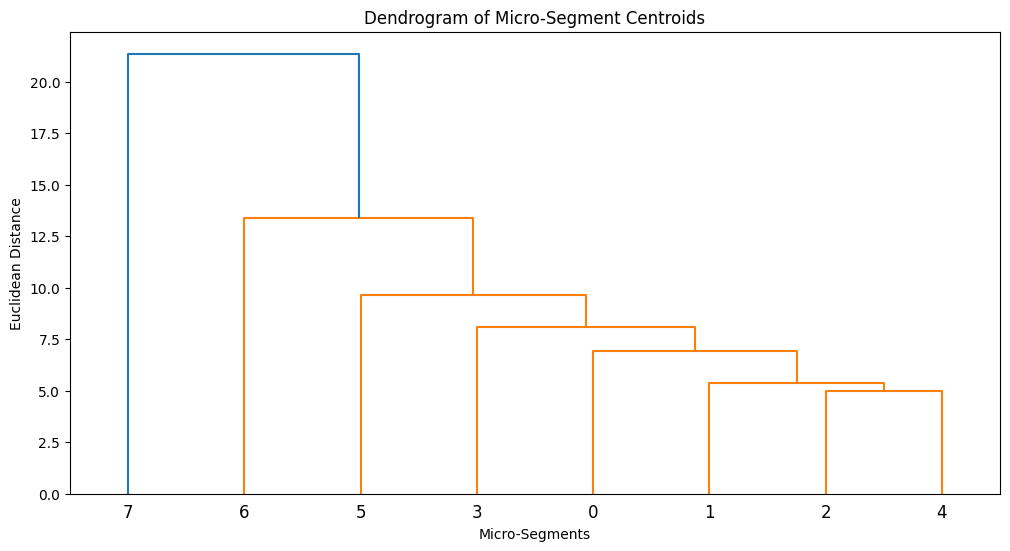

In [11]:
plt.figure(figsize=(12, 6))
plt.title('Dendrogram of Micro-Segment Centroids')
dendrogram = dendrogram(linkage(df_centroids_scaled, method='ward'))
plt.xlabel('Micro-Segments')
plt.ylabel('Euclidean Distance')
plt.show()

In [12]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df_centroids['Final_Cluster_Label'] = hc.fit_predict(df_centroids_scaled)

In [13]:
# Create a mapping dictionary: Micro-Segment -> Final Cluster
micro_to_final_map = df_centroids['Final_Cluster_Label'].to_dict()

# Map the final cluster back to the main customer dataframe
df_merged['Final_Solution_Label'] = df_merged['Micro_Segment'].map(micro_to_final_map)

In [14]:
print("Final Segment Distribution:")
print(df_merged['Final_Solution_Label'].value_counts().sort_index())

# Display a sample of how perspectives were merged
print("\nSample mapping of Perspectives to Final Solution:")
print(df_merged[['Engagement_Label', 'Behavior_Label', 'Value_Label', 'Micro_Segment', 'Final_Solution_Label']].head(10))

Final Segment Distribution:
Final_Solution_Label
0    13660
1      110
2      258
3     1430
4     1237
Name: count, dtype: int64

Sample mapping of Perspectives to Final Solution:
          Engagement_Label  Behavior_Label  Value_Label Micro_Segment  \
Loyalty#                                                                
100011                   1               1            1     1 | 1 | 1   
100012                   4               4            4     4 | 4 | 4   
100013                   5               5            5     5 | 5 | 5   
100014                   3               3            3     3 | 3 | 3   
100015                   4               4            4     4 | 4 | 4   
100016                   5               5            5     5 | 5 | 5   
100017                   5               5            5     5 | 5 | 5   
100018                   5               5            5     5 | 5 | 5   
100102                   1               1            1     1 | 1 | 1   
100140          

# <span style="color:#0097b2">4. Profiling & Interpretation</span>
[Back to TOC](#toc)

In [15]:
# 1. Calculate R2 for ALL variables (Active + Passive)
# (excluding ID columns or text columns)
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
# Remove the cluster labels themselves
numeric_cols = [c for c in numeric_cols if c not in ['Final_Solution_Label', 'Location_cluster', 'EnrollmentType']]

def get_r2_scores(df, cluster_col, features):
    sst_total = df[features].var() * (len(df) - 1)
    r2_scores = {}
    for feature in features:
        sst = sst_total[feature]
        if sst == 0: continue # Skip constant columns
        ssw = 0
        for cluster in df[cluster_col].unique():
            cluster_data = df[df[cluster_col] == cluster][feature]
            ssw += cluster_data.var() * (len(cluster_data) - 1)
        r2_scores[feature] = (sst - ssw) / sst
    return pd.Series(r2_scores).sort_values(ascending=False)

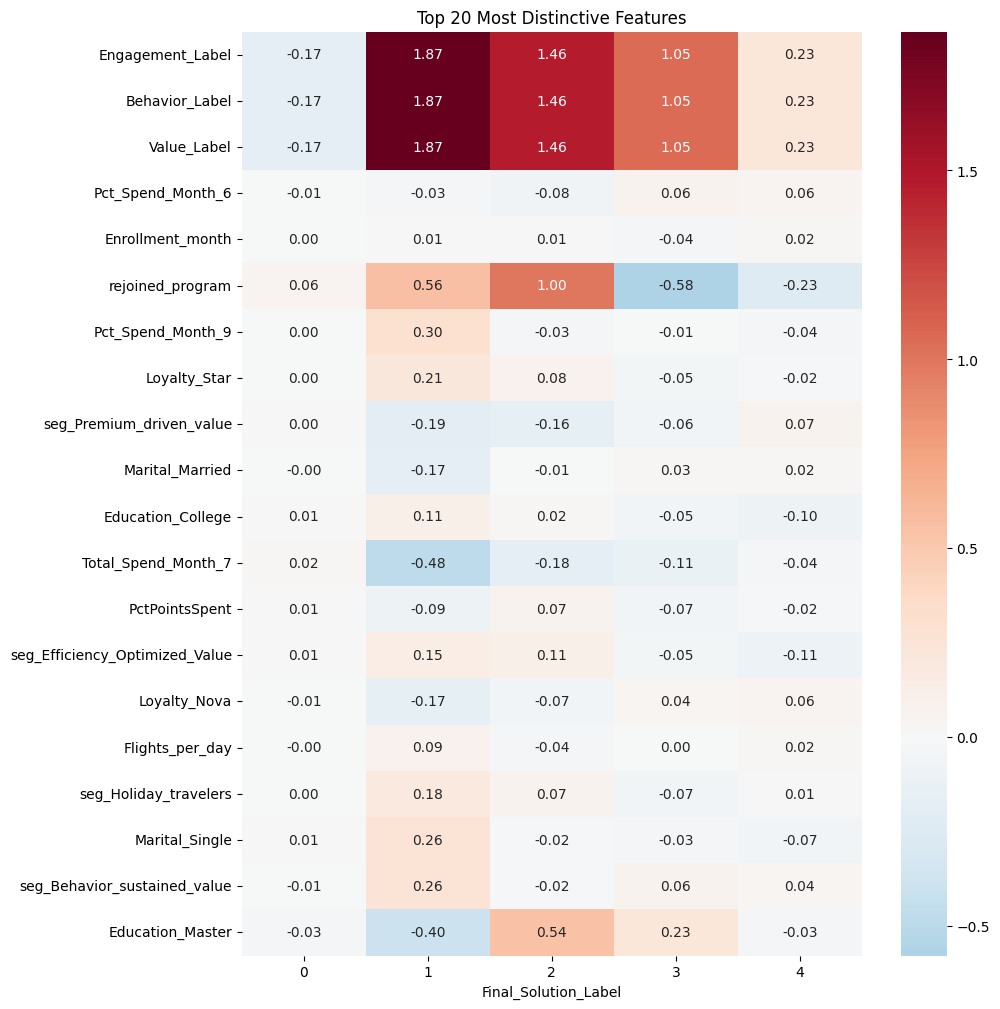

In [16]:
# 2. Get Top 20 Differentiating Features
top_features = get_r2_scores(df_merged, 'Final_Solution_Label', numeric_cols).head(20).index.tolist()

# 3. Plot Heatmap ONLY for these Top 20
cluster_means = df_merged.groupby('Final_Solution_Label')[top_features].mean()
global_means = df_merged[top_features].mean()
relative_imp = (cluster_means / global_means) - 1

plt.figure(figsize=(10, 12))
sns.heatmap(data=relative_imp.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Top 20 Most Distinctive Features')
plt.show()

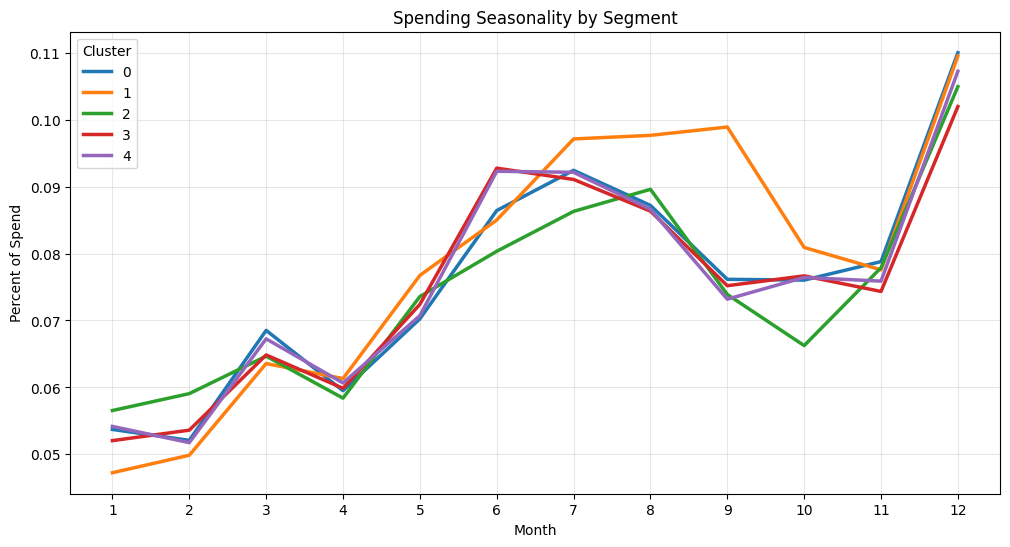

In [17]:
# Create a temporary dataframe for plotting
seasonality_cols = [f'Pct_Spend_Month_{i}' for i in range(1, 13)]

# Group by Cluster and get the mean of monthly spend
monthly_profile = df_merged.groupby('Final_Solution_Label')[seasonality_cols].mean()

# Rename columns to just numbers 1-12 for the X-axis
monthly_profile.columns = range(1, 13)

# Plot
plt.figure(figsize=(12, 6))
# Transpose so Months are on X-axis
sns.lineplot(data=monthly_profile.T, dashes=False, palette='tab10', linewidth=2.5)

plt.title('Spending Seasonality by Segment')
plt.xlabel('Month')
plt.ylabel('Percent of Spend')
plt.xticks(range(1, 13))
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()